# 07 — CYP2D6 Sample Weighting & Hyperparameter Tuning

**Roadmap Step 2**: two independent levers -- inverse-local-density sample
weighting and grid-search hyperparameter tuning -- tested SEPARATELY against
06's CV-residual-excluded (criterion 1) baseline for `chemeleon__rf` and
`chemeleon__lightgbm`. All training/tuning logic lives in
`scripts/cyp2d6_weighting_tuning.py`; this notebook is reporting only.

**Baseline for this step is 06's residual-excluded result**
(`outputs/06_outlier_check/{predictions,scores}/residual__<config>__repeat*_fold*.csv`),
**not 05's original unexcluded models.** Both levers below reuse 06's fixed
training-pool exclusion (the 75 compounds flagged by CV-residual p95,
`outputs/06_outlier_check/flagged_compounds/criterion1_residual_flagged.csv`)
as their own starting training pool. CI-width exclusion (06's criterion 2) is
out of scope here.

## Scope: `chemprop_chemeleoninit` is deferred

`chemprop_chemeleoninit` is explicitly OUT for this entire step -- tabular
configs only (`chemeleon__rf`, `chemeleon__lightgbm`). 06's Sections 5-8 found
that `chemprop_chemeleoninit`'s residual-excluded result is entangled between
a genuine data-quality effect and a leading, unconfirmed hypothesis that
masking CYP2D6 labels implicitly reweights CYP2D6's share of the shared
multitask encoder's loss. Adding a third mechanism (explicit sample
weighting) on top of an already-unresolved two-mechanism baseline would make
attribution substantially harder, so `chemprop_chemeleoninit` is deferred
rather than tested here -- its 06 result (excluded, unweighted, untuned) is
its best-known state going into step 3 unless revisited. `chemeleon__rf` and
`chemeleon__lightgbm` are single-task models with no shared encoder --
unaffected by this mechanism, in scope as originally planned.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "scripts"))

import numpy as np
import pandas as pd
from scipy.stats import shapiro, ttest_rel, wilcoxon

OUT06 = REPO_ROOT / "outputs" / "06_outlier_check"
OUT07 = REPO_ROOT / "outputs" / "07_weighting_tuning"
BASELINE_SCORE_DIR = OUT06 / "scores"
SCORE_DIR = OUT07 / "scores"
WEIGHTING_CHECK_DIR = OUT07 / "weighting_check"
TUNING_SEARCH_DIR = OUT07 / "tuning_search"
FIGURES_DIR = OUT07 / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIGS = ["chemeleon__rf", "chemeleon__lightgbm"]
LEVERS = ["weighting", "tuning"]
METRICS = ["ST-RAE", "R2"]
ALPHA = 0.05
N_REPEATS, N_FOLDS = 5, 5
CYP2D6_COL = "CYP2D6_pIC50_direct_inhibition"

print(f"python: {sys.version.split()[0]}")
print(f"configs: {CONFIGS}")
print(f"levers: {LEVERS}")


python: 3.11.13
configs: ['chemeleon__rf', 'chemeleon__lightgbm']
levers: ['weighting', 'tuning']


## Parameter table

Every parameter tested across both levers, for at-a-glance review. One row
per (lever, config, parameter). Weighting rows show the confirmed scheme's
actual parameters; tuning rows list the grids actually run. This table is
static markdown (not generated by code) so it renders correctly even
without re-running cells.

| Lever | Config | Parameter | Values tested |
|---|---|---|---|
| Weighting | chemeleon__rf | density estimator | Gaussian KDE (`scipy.stats.gaussian_kde`), Scott's-rule bandwidth |
| Weighting | chemeleon__rf | fit scope | refit per fold, on that fold's own post-exclusion training pool (`screen_inner_train` + `screen_inner_val`) -- not global |
| Weighting | chemeleon__rf | weight formula | `1 / density(pIC50)`, normalized to mean 1.0 within the fold's pool |
| Weighting | chemeleon__rf | clip cap | 5.0x the fold's own mean weight |
| Weighting | chemeleon__lightgbm | density estimator | Gaussian KDE (`scipy.stats.gaussian_kde`), Scott's-rule bandwidth |
| Weighting | chemeleon__lightgbm | fit scope | refit per fold, on that fold's own post-exclusion training pool (`screen_inner_train` + `screen_inner_val`) -- not global |
| Weighting | chemeleon__lightgbm | weight formula | `1 / density(pIC50)`, normalized to mean 1.0 within the fold's pool |
| Weighting | chemeleon__lightgbm | clip cap | 5.0x the fold's own mean weight |
| Tuning | chemeleon__rf | n_estimators | {200, 500, 1000} -- reduced from {200, 500, 1000, **1500**}, see note below |
| Tuning | chemeleon__rf | max_depth | {10, 20} -- reduced from {**None**, 10, 20, **30**}, see note below |
| Tuning | chemeleon__rf | min_samples_leaf | {1, 2, 3, 5} -- unchanged |
| Tuning | chemeleon__lightgbm | num_leaves | {15, 31, 63, 127} -- unchanged |
| Tuning | chemeleon__lightgbm | learning_rate | {0.01, 0.03, 0.05, 0.1} -- unchanged |
| Tuning | chemeleon__lightgbm | min_child_samples | {5, 10, 20, 30} -- unchanged |

Each config's grid is searched on the inner train/validation split within
each of the 25 outer folds separately ("one iteration of the inner loop of
nested CV" -- Ash et al., 5x5 CV paper, Section 3.1.4), not a second nested
CV layered across all 25 outer folds. Hyperparameter selection within each
fold's search uses plain RAE (`src.vendor.openadmet_eval.custom_scoring_functions.rae`,
undecorated, no CI soft-thresholding) on that fold's `screen_inner_val`
predictions -- a deliberate simplification for this internal step only; the
before/after comparison below still uses the project's real bootstrapped
ST-RAE, exactly as 06 did.

**RF grid reduced, 64 -> 24 combos (2026-09-03, confirmed with the user --
a documented, justified scope change, not a silent cut).** The original
64-combo RF grid ({200,500,1000,1500} x {None,10,20,30} x {1,2,3,5}) was
taking over an hour per fold (~24-30h projected for all 25 folds) -- that
runtime cost is what surfaced the question, but the reduction itself rests
on two independent, converging reasons, not runtime alone:

1. **Overfitting territory.** With only 3,335 inner-training compounds and
   `min_samples_leaf` already searched down to 1, unrestricted-depth trees
   (`max_depth=None`) at 1,500 estimators sit deep in overfitting territory
   for a dataset this size -- unlikely to be where this grid's useful signal
   lives.
2. **Consistent with the weighting lever's own result.** Section 3 above
   found the weighting lever's dramatic distribution manipulation
   (down-weighting the dense middle to ~0.39x, boosting rare tails up to
   5.0x) cost far more accuracy than it recovered. That result is
   independent evidence, on this same CYP2D6 dataset, that extreme
   parameter choices are not where the useful signal is -- making a
   narrower, less-extreme RF grid a proportionate, evidence-consistent
   choice rather than an arbitrary compute-driven cut.

`n_estimators=1500` and `max_depth in {None, 30}` are dropped; `n_estimators`
up to 1000, `max_depth` in {10, 20}, and the full `min_samples_leaf` range
remain. `chemeleon__lightgbm`'s grid (also 64 combos, ~75s/fold) was left
untouched -- it was never the runtime bottleneck. `n_jobs=-1` was already
set on every RF fit before this change (confirmed, not added as part of the
fix) -- it doesn't change results (sklearn's RF is bit-identical regardless
of `n_jobs` for a fixed `random_state`), only wall-clock time.

**Asymmetry, disclosed explicitly (corrected from the task's original
framing on 2026-09-03, see Section 1 below):** weighting is NOT frozen once
globally -- it is refit per fold, for the same fold-isolation reason tuning's
search already respects. What both levers actually share is that neither
ever touches a fold's own `screen_test` compounds when fitting anything
(weights or hyperparameters) for that fold.


## 1. Weighting scheme -- confirmation history

**Original proposal**: Gaussian KDE (Scott's-rule bandwidth) fit ONCE,
globally, on all 1,493 CYP2D6-labeled compounds in
`train_inhibition_curated.csv`, frozen for all 25 folds -- matching the
task's original "weighting frozen once for all folds" framing.

**User feedback (2026-09-03)**: a single global fit uses each fold's own
held-out `screen_test` compounds' pIC50 values to shape that very fold's
training weights -- a leakage risk, given how the rest of this project
handles fold isolation (e.g. tuning's own inner-split-only search). The
scheme was corrected to refit the KDE **per fold**, using only that fold's
own post-exclusion training pool (`screen_inner_train` + `screen_inner_val`,
CYP2D6-labeled, criterion-1-flagged compounds already dropped) -- never that
fold's `screen_test` compounds.

**Confirmed scheme** (`compute_fold_cyp2d6_weights`,
`scripts/cyp2d6_weighting_tuning.py`): per fold, Gaussian KDE (Scott's-rule
bandwidth) on that fold's training-pool pIC50 values; raw weight =
1/density(pIC50); normalized to mean 1.0 within that pool; clipped at 5.0x
the pool's own mean.

The distribution below is the per-fold sanity check shown to the user for
final confirmation, loaded here from
`outputs/07_weighting_tuning/weighting_check/` (written by
`scripts/cyp2d6_weighting_tuning.py --weighting-check`, not recomputed in
this notebook).


In [2]:
weights_per_fold = pd.read_csv(WEIGHTING_CHECK_DIR / "cyp2d6_sample_weights_per_fold.csv")
fold_summary = pd.read_csv(WEIGHTING_CHECK_DIR / "cyp2d6_sample_weights_per_fold_summary.csv")

print(f"weights_per_fold: {weights_per_fold.shape} (25 folds x ~1,110-1,155 pool compounds each)")
print(f"\nper-fold pool size: min={fold_summary['size'].min()}, max={fold_summary['size'].max()}")
print(f"per-fold weight mean: mean-of-means={fold_summary['mean'].mean():.4f}, "
      f"std-of-means={fold_summary['mean'].std():.4f}")
print("\npooled weight distribution across all 25 folds:")
print(weights_per_fold["weight"].describe().to_string())


weights_per_fold: (28360, 8) (25 folds x ~1,110-1,155 pool compounds each)

per-fold pool size: min=1111, max=1154
per-fold weight mean: mean-of-means=0.7785, std-of-means=0.0148

pooled weight distribution across all 25 folds:
count    28360.000000
mean         0.778460
std          1.129256
min          0.233792
25%          0.261491
50%          0.364868
75%          0.582974
max          5.000000


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/figures/weight_distribution_confirmed.png


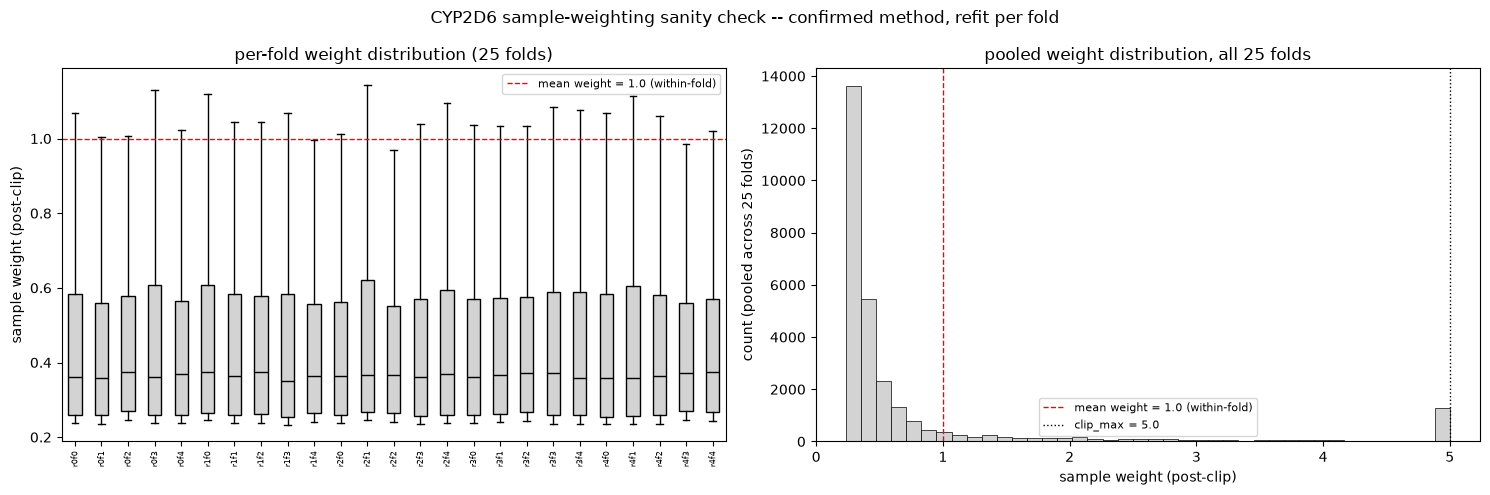

In [3]:
import matplotlib.pyplot as plt

CLIP_MAX = 5.0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fold_order = [(r, f) for r in range(N_REPEATS) for f in range(N_FOLDS)]
fold_labels = [f"r{r}f{f}" for r, f in fold_order]
box_data = [
    weights_per_fold.loc[(weights_per_fold["repeat"] == r) & (weights_per_fold["fold"] == f), "weight"]
    for r, f in fold_order
]
axes[0].boxplot(box_data, tick_labels=fold_labels, showfliers=False, patch_artist=True,
                 boxprops={"facecolor": "lightgray"}, medianprops={"color": "black"})
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=1, label="mean weight = 1.0 (within-fold)")
axes[0].set_xticklabels(fold_labels, rotation=90, fontsize=6)
axes[0].set_ylabel("sample weight (post-clip)")
axes[0].set_title("per-fold weight distribution (25 folds)")
axes[0].legend(fontsize=8)

axes[1].hist(weights_per_fold["weight"], bins=40, color="lightgray", edgecolor="black", linewidth=0.5)
axes[1].axvline(1.0, color="red", linestyle="--", linewidth=1, label="mean weight = 1.0 (within-fold)")
axes[1].axvline(CLIP_MAX, color="black", linestyle=":", linewidth=1, label=f"clip_max = {CLIP_MAX}")
axes[1].set_xlabel("sample weight (post-clip)")
axes[1].set_ylabel("count (pooled across 25 folds)")
axes[1].set_title("pooled weight distribution, all 25 folds")
axes[1].legend(fontsize=8)

fig.suptitle("CYP2D6 sample-weighting sanity check -- confirmed method, refit per fold")
plt.tight_layout()
path = FIGURES_DIR / "weight_distribution_confirmed.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
print(f"wrote {path}")
plt.show()


**What this shows:** weight distributions are near-identical across all 25
folds (mean-of-per-fold-means and std-of-per-fold-means printed above show
how tight this is) -- expected, since each fold's training pool overlaps
heavily with every other fold's (only ~1/5 of labeled compounds rotate out
as that fold's own test set at a time), confirming the per-fold refit
doesn't introduce meaningful fold-to-fold instability into the scheme. The
shape matches the original global-fit proposal (dense middle of the pIC50
distribution downweighted below 1.0, sparse tails boosted up to the 5.0x
clip cap) -- refitting per fold changed *which* compounds' labels can
influence a given fold's weights (leakage fix), not the qualitative shape of
the scheme.


## 2. Before/after CV comparison -- shared method (both levers)

**Statistical method -- same as 06, applied here to a different "after".**
For each (config, lever, metric): compute the 25 per-fold deltas (after -
before), Shapiro-Wilk test on those deltas, paired t-test if Shapiro-Wilk
does not reject normality (p >= 0.05) else Wilcoxon signed-rank. No BH
correction and no cross-metric Bonferroni gate (same reasoning as 06: both
are calibrated for 05's joint 5-metric, many-group screen, not this 2-metric
before/after check). Only ST-RAE and R2 are tested; each (config, lever,
metric) gets its own test at alpha=0.05, uncorrected across the 2 configs x
2 levers x 2 metrics = 8 total tests below.

**"Before" is asserted, in code, to match 06's residual-excluded result**
(`criterion=residual` in `outputs/06_outlier_check/scores/`) -- not 05's
original baseline -- via the same fold-order-alignment assertion 06 used
before pairing.


In [4]:
def load_fold_scores(score_dir, tag_fn, configs):
    """One row per (config, repeat, fold) with mean ST-RAE/R2 (mean of the
    1,000-sample bootstrap distribution -- matches 05/06's own aggregation
    convention) for CYP2D6, from score CSVs at `score_dir / f"{tag_fn(config, r, f)}.csv"`.
    """
    rows = []
    for config in configs:
        for repeat in range(N_REPEATS):
            for fold in range(N_FOLDS):
                path = score_dir / f"{tag_fn(config, repeat, fold)}.csv"
                df = pd.read_csv(path)
                pe = df.groupby("Endpoint")[METRICS].mean()
                row = {"config": config, "repeat": repeat, "fold": fold}
                for m in METRICS:
                    row[m] = pe.loc[CYP2D6_COL, m]
                rows.append(row)
    return pd.DataFrame(rows)


def paired_comparison(before_df, after_df, configs, metrics, lever_name):
    """Per (config, metric): Shapiro-Wilk on the 25 deltas, paired t-test if
    normal else Wilcoxon signed-rank. Asserts before/after fold order aligns
    before pairing (same discipline as 06).
    """
    results = []
    for config in configs:
        sub_before = before_df[before_df["config"] == config].sort_values(["repeat", "fold"]).reset_index(drop=True)
        sub_after = after_df[after_df["config"] == config].sort_values(["repeat", "fold"]).reset_index(drop=True)
        assert len(sub_before) == 25 and len(sub_after) == 25, f"{config}: expected 25 folds each side"
        assert (sub_before[["repeat", "fold"]].to_numpy() == sub_after[["repeat", "fold"]].to_numpy()).all(), \
            f"{config}: before/after fold order mismatch -- paired test would be invalid"

        for metric in metrics:
            before = sub_before[metric].to_numpy()
            after = sub_after[metric].to_numpy()
            delta = after - before

            shapiro_p = float(shapiro(delta).pvalue)
            normal = shapiro_p >= ALPHA
            if normal:
                test_name = "paired t-test"
                _, p_value = ttest_rel(after, before)
            else:
                test_name = "Wilcoxon signed-rank"
                _, p_value = wilcoxon(delta)

            results.append({
                "lever": lever_name, "config": config, "metric": metric,
                "before_mean": before.mean(), "after_mean": after.mean(), "delta_mean": delta.mean(),
                "shapiro_p": shapiro_p, "branch": "parametric" if normal else "nonparametric",
                "test": test_name, "p_value": float(p_value), "significant": bool(p_value < ALPHA),
            })
    return pd.DataFrame(results)


baseline_df = load_fold_scores(BASELINE_SCORE_DIR, lambda c, r, f: f"residual__{c}__repeat{r}_fold{f}", CONFIGS)
print(f"baseline_df (06 residual-excluded): {baseline_df.shape} (expect (50, 5): 2 configs x 25 folds)")

# sanity check against 06's own before_after_comparison.csv: 06's "after" (residual-excluded)
# is this notebook's "before" -- confirm point estimates match to the float, not just row counts.
outcome_06 = pd.read_csv(OUT06 / "before_after_comparison.csv")
for config in CONFIGS:
    for metric in METRICS:
        ours = baseline_df.loc[baseline_df["config"] == config, metric].mean()
        theirs = outcome_06.loc[
            (outcome_06["criterion"] == "residual") & (outcome_06["config"] == config) & (outcome_06["metric"] == metric),
            "after_mean",
        ].iloc[0]
        assert np.isclose(ours, theirs), f"{config}/{metric}: baseline mismatch vs 06's own after_mean ({ours} != {theirs})"
print("confirmed: baseline_df's per-config mean matches 06's own residual-excluded after_mean exactly, for both metrics.")


baseline_df (06 residual-excluded): (50, 5) (expect (50, 5): 2 configs x 25 folds)
confirmed: baseline_df's per-config mean matches 06's own residual-excluded after_mean exactly, for both metrics.


## 3. Weighting lever -- before/after CV comparison

"After" here is the per-fold-refit weighted retrain (`lever=weighting`,
`outputs/07_weighting_tuning/scores/weighting__<config>__repeat*_fold*.csv`).
Hyperparameters are unchanged from the 06 baseline (sklearn defaults,
`random_state=seed`) -- sample weighting is the only difference.


In [5]:
weighting_after_df = load_fold_scores(SCORE_DIR, lambda c, r, f: f"weighting__{c}__repeat{r}_fold{f}", CONFIGS)
print(f"weighting_after_df: {weighting_after_df.shape} (expect (50, 5))")

weighting_results = paired_comparison(baseline_df, weighting_after_df, CONFIGS, METRICS, "weighting")
weighting_results_path = OUT07 / "weighting_before_after_comparison.csv"
weighting_results.to_csv(weighting_results_path, index=False)
print(f"wrote {weighting_results_path}")

pd.set_option("display.width", 160)
weighting_results


weighting_after_df: (50, 5) (expect (50, 5))
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/weighting_before_after_comparison.csv


,lever,config,metric,before_mean,after_mean,delta_mean,shapiro_p,branch,test,p_value,significant
0,weighting,chemeleon__rf,ST-RAE,0.902073,0.978860,0.076787,0.331023,parametric,paired t-test,2.421554e-11,True
1,weighting,chemeleon__rf,R2,0.135805,0.105129,-0.030676,0.156870,parametric,paired t-test,1.596419e-04,True
2,weighting,chemeleon__lightgbm,ST-RAE,0.930195,0.992080,0.061885,0.437754,parametric,paired t-test,3.332141e-11,True
3,weighting,chemeleon__lightgbm,R2,0.106032,0.053040,-0.052992,0.841886,parametric,paired t-test,1.264782e-07,True


**What this shows:** the weighting lever **significantly worsens both
metrics for both configs.** ST-RAE increases (worse) for `chemeleon__rf`
(0.902 -> 0.979, p=2.4e-11) and `chemeleon__lightgbm` (0.930 -> 0.992,
p=3.3e-11); R2 drops for both too (`chemeleon__rf`: 0.136 -> 0.105,
p=1.6e-4; `chemeleon__lightgbm`: 0.106 -> 0.053, p=1.3e-7). All four
(config, metric) pairs are significant in the same, unwanted direction. The
inverse-local-density scheme deliberately downweights the dense middle of
the pIC50 distribution (median weight 0.39, vs. 1.0 for an unweighted fit)
to boost the sparse high/low-potency tails (up to the 5.0x clip) -- but most
`screen_test` compounds also live in that dense middle, so the model is
trained with systematically less signal from the region most of its test
compounds actually fall in. This is a genuine, reportable negative result,
not a bug: rebalancing toward rare potency values costs typical-potency
accuracy, and here that cost outweighs any tail-compound benefit on both of
this task's headline metrics.


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/figures/weighting_before_after_distributions.png


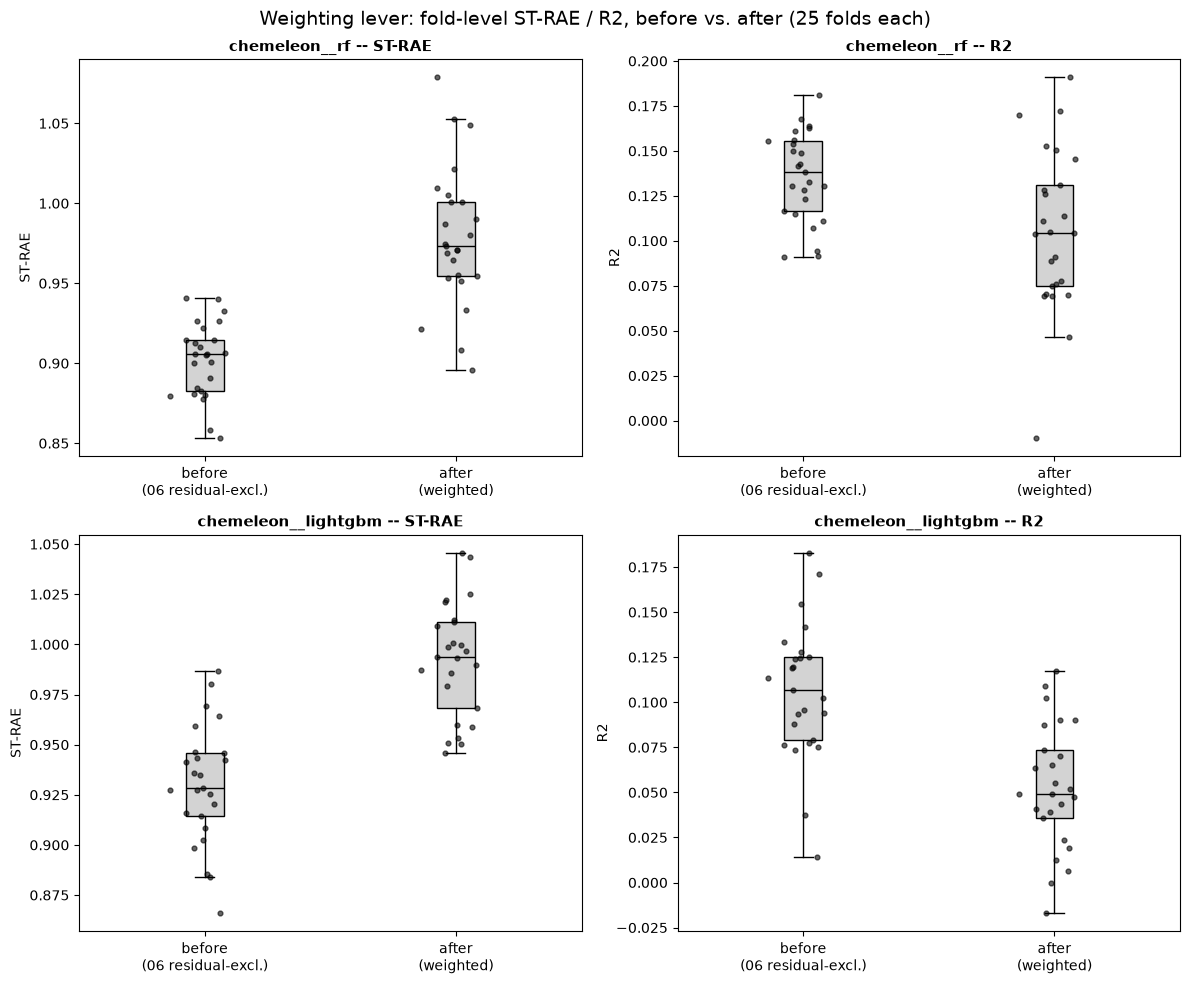

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row, config in enumerate(CONFIGS):
    for col, metric in enumerate(METRICS):
        ax = axes[row, col]
        sub_before = baseline_df.loc[baseline_df["config"] == config, metric].to_numpy()
        sub_after = weighting_after_df.loc[weighting_after_df["config"] == config, metric].to_numpy()
        data = [sub_before, sub_after]
        bp = ax.boxplot(data, tick_labels=["before\n(06 residual-excl.)", "after\n(weighted)"],
                         showfliers=False, patch_artist=True,
                         boxprops={"facecolor": "lightgray"}, medianprops={"color": "black"})
        for i, vals in enumerate(data, start=1):
            jitter = np.random.default_rng(0).normal(0, 0.06, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, color="black", s=12, alpha=0.6, zorder=3)
        ax.set_title(f"{config} -- {metric}", fontsize=11, fontweight="bold")
        ax.set_ylabel(metric)

fig.suptitle("Weighting lever: fold-level ST-RAE / R2, before vs. after (25 folds each)", fontsize=14)
plt.tight_layout()
path = FIGURES_DIR / "weighting_before_after_distributions.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
print(f"wrote {path}")
plt.show()


**What this shows:** the ST-RAE and R2 shifts hold consistently across
folds, not driven by a handful of outliers -- for both configs, nearly the
entire "after" box sits clearly above (ST-RAE, worse) or below (R2, worse)
the "before" box, with substantial before/after separation and only mild
overlap at the extremes. This is a broad, fold-general degradation, not an
artifact of a few unlucky folds.


## 4. Tuning lever -- before/after CV comparison

"After" here is the per-fold grid-searched retrain (`lever=tuning`,
`outputs/07_weighting_tuning/scores/tuning__<config>__repeat*_fold*.csv`).
Sample weighting is NOT applied here -- the two levers are tested
independently, per task spec.


In [7]:
tuning_after_df = load_fold_scores(SCORE_DIR, lambda c, r, f: f"tuning__{c}__repeat{r}_fold{f}", CONFIGS)
print(f"tuning_after_df: {tuning_after_df.shape} (expect (50, 5))")

tuning_results = paired_comparison(baseline_df, tuning_after_df, CONFIGS, METRICS, "tuning")
tuning_results_path = OUT07 / "tuning_before_after_comparison.csv"
tuning_results.to_csv(tuning_results_path, index=False)
print(f"wrote {tuning_results_path}")

tuning_results


tuning_after_df: (50, 5) (expect (50, 5))
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/tuning_before_after_comparison.csv


,lever,config,metric,before_mean,after_mean,delta_mean,shapiro_p,branch,test,p_value,significant
0,tuning,chemeleon__rf,ST-RAE,0.902073,0.896770,-0.005304,0.200234,parametric,paired t-test,0.013493,True
1,tuning,chemeleon__rf,R2,0.135805,0.139961,0.004156,0.564255,parametric,paired t-test,0.035836,True
2,tuning,chemeleon__lightgbm,ST-RAE,0.930195,0.926399,-0.003796,0.496202,parametric,paired t-test,0.394674,False
3,tuning,chemeleon__lightgbm,R2,0.106032,0.110293,0.004261,0.012384,nonparametric,Wilcoxon signed-rank,0.181730,False


**What this shows:** tuning's effect is small in both directions.
`chemeleon__rf` shows a small but **significant** improvement on both
metrics: ST-RAE 0.902 -> 0.897 (p=0.013) and R2 0.136 -> 0.140 (p=0.036).
`chemeleon__lightgbm` shows similarly small shifts in the same favorable
direction (ST-RAE 0.930 -> 0.926, R2 0.106 -> 0.110) but neither reaches
significance (p=0.39, p=0.18). Grid search on the reduced RF grid (24
combos, see the parameter-table note above) found a real, if modest,
improvement; on the LightGBM grid (64 combos, unchanged) it found a
same-direction trend too small to distinguish from noise at alpha=0.05.
Unlike weighting, tuning never moves either metric in the *wrong* direction
for either config.


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/figures/tuning_before_after_distributions.png


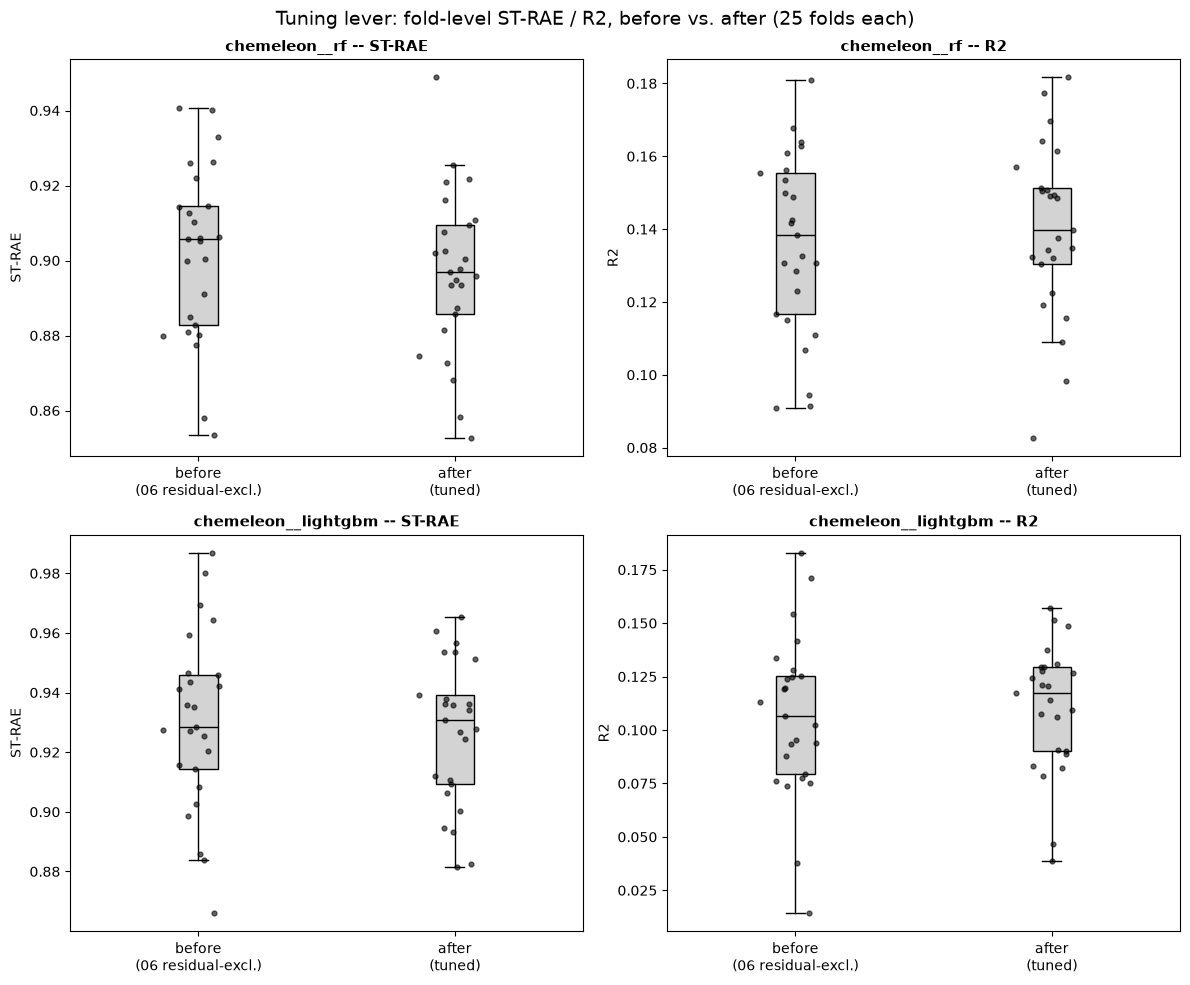

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row, config in enumerate(CONFIGS):
    for col, metric in enumerate(METRICS):
        ax = axes[row, col]
        sub_before = baseline_df.loc[baseline_df["config"] == config, metric].to_numpy()
        sub_after = tuning_after_df.loc[tuning_after_df["config"] == config, metric].to_numpy()
        data = [sub_before, sub_after]
        bp = ax.boxplot(data, tick_labels=["before\n(06 residual-excl.)", "after\n(tuned)"],
                         showfliers=False, patch_artist=True,
                         boxprops={"facecolor": "lightgray"}, medianprops={"color": "black"})
        for i, vals in enumerate(data, start=1):
            jitter = np.random.default_rng(0).normal(0, 0.06, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, color="black", s=12, alpha=0.6, zorder=3)
        ax.set_title(f"{config} -- {metric}", fontsize=11, fontweight="bold")
        ax.set_ylabel(metric)

fig.suptitle("Tuning lever: fold-level ST-RAE / R2, before vs. after (25 folds each)", fontsize=14)
plt.tight_layout()
path = FIGURES_DIR / "tuning_before_after_distributions.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
print(f"wrote {path}")
plt.show()


**What this shows:** in sharp visual contrast to the weighting plot, the
before/after boxes overlap heavily here for both configs and both metrics --
consistent with the small effect sizes and (for `chemeleon__lightgbm`)
non-significance above. For `chemeleon__rf`, the "after" box is shifted
slightly lower (ST-RAE) / higher (R2) than "before," but the bulk of both
distributions occupies the same range -- a real, consistent, but modest
shift, not a dramatic separation. This is the expected visual signature of
a small-but-significant paired effect: individually noisy per-fold points,
but a consistent enough direction across 25 folds for the paired test to
detect it.


## 5. Tuning search landscape

Mean inner-validation RAE across the 25 folds' grid searches, for each
(config, grid point) -- enough to judge whether the search found a
meaningfully better region or whether performance is flat across most of the
grid. RF's 3-parameter grid is faceted by `min_samples_leaf` (heatmap axes:
`n_estimators` x `max_depth`); LightGBM's is faceted by `min_child_samples`
(heatmap axes: `num_leaves` x `learning_rate`).


In [9]:
# NOTE: RF's grid was reduced on 2026-09-03 (see parameter-table cell above for the
# full, confirmed reasoning) from 64 to 24 combos: n_estimators {200,500,1000} x
# max_depth {10,20} x min_samples_leaf {1,2,3,5}. max_depth no longer includes `None`
# in the reduced grid, but the NaN-handling below is kept anyway as a defensive
# safeguard: `None` written to CSV round-trips as an empty field -> NaN (a float
# column), and pandas' groupby/pivot both drop NaN keys by default -- silently losing
# grid points if that value is ever reintroduced. Converted to the string sentinel
# "None" right after loading, before any groupby/pivot touches it.

def load_search_landscape(config, param_cols):
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            path = TUNING_SEARCH_DIR / f"{config}__repeat{repeat}_fold{fold}.csv"
            rows.append(pd.read_csv(path))
    df = pd.concat(rows, ignore_index=True)
    if "max_depth" in df.columns:
        df["max_depth"] = df["max_depth"].apply(lambda v: "None" if pd.isna(v) else str(int(v)))
    print(f"{config}: {df.shape} rows loaded ({df[param_cols].drop_duplicates().shape[0]} unique grid points x 25 folds expected)")
    landscape = df.groupby(param_cols, dropna=False)["inner_val_RAE"].mean().reset_index()
    return df, landscape


rf_search_df, rf_landscape = load_search_landscape("chemeleon__rf", ["n_estimators", "max_depth", "min_samples_leaf"])
lgbm_search_df, lgbm_landscape = load_search_landscape("chemeleon__lightgbm", ["num_leaves", "learning_rate", "min_child_samples"])

assert len(rf_landscape) == 24, f"expected 24 RF grid points in the landscape (reduced grid, 2026-09-03), got {len(rf_landscape)} -- a grid point was silently dropped"
assert len(lgbm_landscape) == 64, f"expected 64 LightGBM grid points in the landscape, got {len(lgbm_landscape)}"

print("\nchemeleon__rf best (lowest mean inner_val_RAE) grid point:")
print(rf_landscape.loc[rf_landscape["inner_val_RAE"].idxmin()])
print("\nchemeleon__lightgbm best (lowest mean inner_val_RAE) grid point:")
print(lgbm_landscape.loc[lgbm_landscape["inner_val_RAE"].idxmin()])


chemeleon__rf: (600, 7) rows loaded (24 unique grid points x 25 folds expected)
chemeleon__lightgbm: (1600, 7) rows loaded (64 unique grid points x 25 folds expected)

chemeleon__rf best (lowest mean inner_val_RAE) grid point:
n_estimators            1000
max_depth                 10
min_samples_leaf           5
inner_val_RAE       0.915303
Name: 19, dtype: object

chemeleon__lightgbm best (lowest mean inner_val_RAE) grid point:
num_leaves           15.000000
learning_rate         0.050000
min_child_samples    20.000000
inner_val_RAE         0.916057
Name: 10, dtype: float64


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/figures/tuning_landscape_chemeleon__rf.png


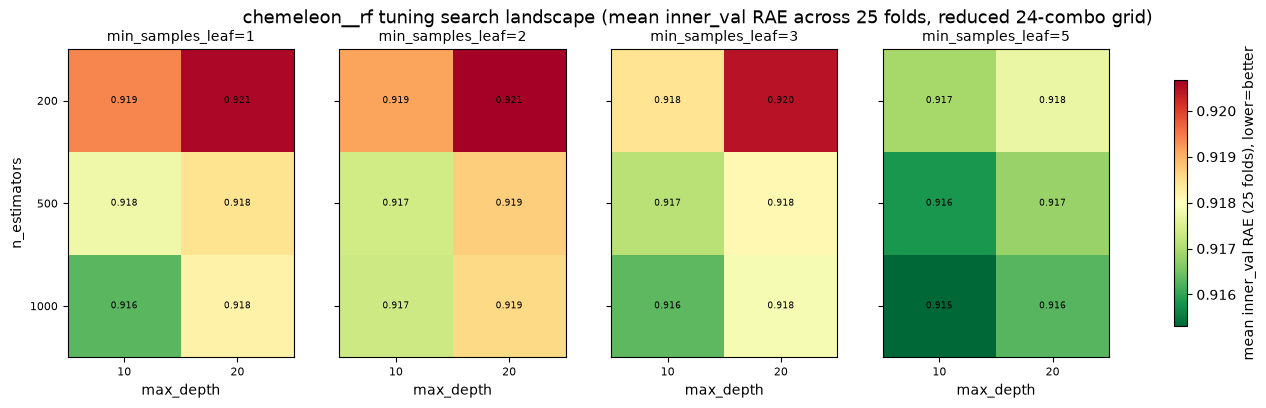

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/figures/tuning_landscape_chemeleon__lightgbm.png


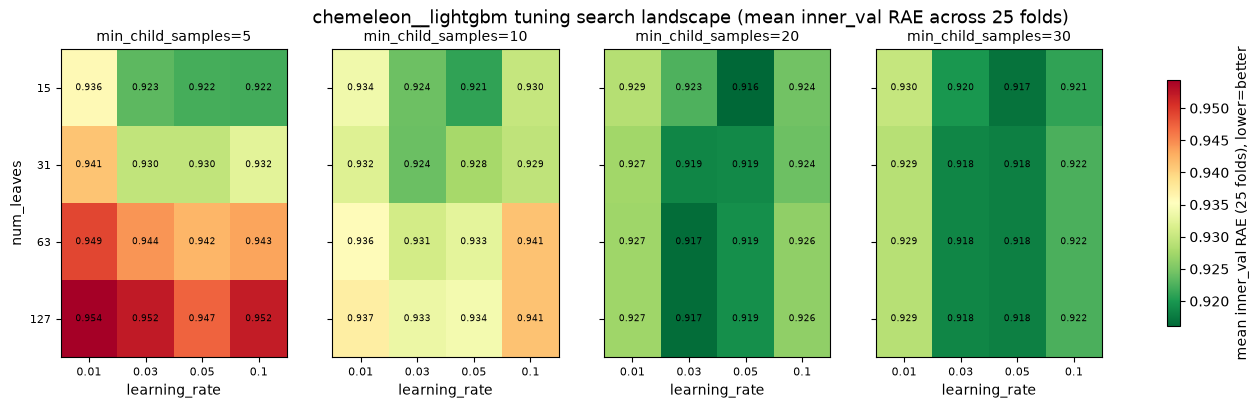

In [10]:
# Explicit axis orders (not pandas' default sort) so RF's "None" sentinel (kept as a
# defensive case, see previous cell) would land where it belongs (unbounded depth)
# rather than wherever string/numeric mixed-type sorting would otherwise place it --
# moot for the reduced grid actually run (max_depth in {10, 20} only) but harmless to
# keep in case the grid is ever widened back.
RF_MAX_DEPTH_ORDER = ["10", "20", "30", "None"]
RF_N_ESTIMATORS_ORDER = [200, 500, 1000]
RF_MIN_SAMPLES_LEAF_ORDER = [1, 2, 3, 5]
LGBM_NUM_LEAVES_ORDER = [15, 31, 63, 127]
LGBM_LEARNING_RATE_ORDER = [0.01, 0.03, 0.05, 0.1]
LGBM_MIN_CHILD_SAMPLES_ORDER = [5, 10, 20, 30]


def facet_heatmap(landscape, row_param, col_param, facet_param, row_order, col_order, facet_order, title, path):
    # Only keep axis values actually present in this landscape -- RF_MAX_DEPTH_ORDER
    # etc. above are a superset (covers a possible future wider grid); reindexing with
    # unused values would just produce all-NaN rows/columns.
    row_order = [v for v in row_order if v in landscape[row_param].unique()]
    col_order = [v for v in col_order if v in landscape[col_param].unique()]
    facet_order = [v for v in facet_order if v in landscape[facet_param].unique()]

    fig, axes = plt.subplots(1, len(facet_order), figsize=(4.2 * len(facet_order), 4), sharey=True)
    if len(facet_order) == 1:
        axes = [axes]
    vmin, vmax = landscape["inner_val_RAE"].min(), landscape["inner_val_RAE"].max()
    im = None
    for ax, fval in zip(axes, facet_order):
        sub = landscape[landscape[facet_param] == fval]
        pivot = sub.pivot(index=row_param, columns=col_param, values="inner_val_RAE").reindex(index=row_order, columns=col_order)
        im = ax.imshow(pivot.to_numpy(), cmap="RdYlGn_r", vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_xlabel(col_param)
        if ax is axes[0]:
            ax.set_ylabel(row_param)
        ax.set_title(f"{facet_param}={fval}", fontsize=10)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.to_numpy()[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=6.5)
    fig.colorbar(im, ax=axes, label="mean inner_val RAE (25 folds), lower=better", shrink=0.8)
    fig.suptitle(title, fontsize=13)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"wrote {path}")
    plt.show()


facet_heatmap(
    rf_landscape, row_param="n_estimators", col_param="max_depth", facet_param="min_samples_leaf",
    row_order=RF_N_ESTIMATORS_ORDER, col_order=RF_MAX_DEPTH_ORDER, facet_order=RF_MIN_SAMPLES_LEAF_ORDER,
    title="chemeleon__rf tuning search landscape (mean inner_val RAE across 25 folds, reduced 24-combo grid)",
    path=FIGURES_DIR / "tuning_landscape_chemeleon__rf.png",
)
facet_heatmap(
    lgbm_landscape, row_param="num_leaves", col_param="learning_rate", facet_param="min_child_samples",
    row_order=LGBM_NUM_LEAVES_ORDER, col_order=LGBM_LEARNING_RATE_ORDER, facet_order=LGBM_MIN_CHILD_SAMPLES_ORDER,
    title="chemeleon__lightgbm tuning search landscape (mean inner_val RAE across 25 folds)",
    path=FIGURES_DIR / "tuning_landscape_chemeleon__lightgbm.png",
)


**What this shows:** both landscapes have a real, interpretable best region
rather than being flat, but neither is dramatic.

`chemeleon__rf` (reduced 24-combo grid): the full range is narrow
(0.915-0.921, ~0.6% relative), with a mild, consistent trend along each
axis -- `min_samples_leaf=5` (mean RAE 0.9165 vs. 0.9184-0.9186 for
1/2/3) and `max_depth=10` (0.9173 vs. 0.9185 for `max_depth=20`) are both
clearly better on average, supporting the parameter-table's overfitting
reasoning for dropping `max_depth in {None, 30}`. `n_estimators` also
improves monotonically (0.9192 -> 0.9175 -> 0.9170 for 200/500/1000), but
with **diminishing returns** -- the 200->500 step gains 3x more than the
500->1000 step -- suggesting 1000 is close to where more trees stop
helping, some indirect evidence that dropping `n_estimators=1500` cost
little even though the winning point (`n_estimators=1000`, `max_depth=10`,
`min_samples_leaf=5`, RAE=0.9153) does sit at this grid's upper boundary
for `n_estimators` and `min_samples_leaf`. This can't fully rule out a
further-away combination doing marginally better, but the flatness of the
curve here makes that unlikely to matter in practice.

`chemeleon__lightgbm` (unchanged 64-combo grid): a wider, clearer pattern.
`min_child_samples=5` (least regularization) is consistently and
substantially worst (RAE up to 0.954) regardless of `num_leaves` or
`learning_rate` -- classic overfitting on tiny leaves. `min_child_samples`
20-30 with `learning_rate` 0.03-0.05 forms a consistently good region
(RAE ~0.917-0.919), comfortably inside this grid's range rather than at a
boundary; `num_leaves` matters much less once `min_child_samples` is
adequate. Best point: `num_leaves=15`, `learning_rate=0.05`,
`min_child_samples=20` (RAE=0.9161).


## 6. Outcome -- which version wins, per config

**Decision rule** (stated explicitly): for each config, compare the
baseline (06 residual-excluded) against the weighted and tuned ST-RAE means.
A lever is only considered a candidate winner if its ST-RAE improvement over
baseline is statistically significant (Section 3/4 above); among candidate
winners (baseline is always a candidate), the one with the lowest mean
ST-RAE is recommended for step 3. If neither lever improves significantly,
the baseline (06 residual-excluded, unweighted, untuned) remains the
recommendation.


In [11]:
def summarize_winner(config):
    base_st_rae = baseline_df.loc[baseline_df["config"] == config, "ST-RAE"].mean()
    candidates = {"baseline (06 residual-excluded)": (base_st_rae, True)}

    w_row = weighting_results[(weighting_results["config"] == config) & (weighting_results["metric"] == "ST-RAE")].iloc[0]
    candidates["weighted"] = (w_row["after_mean"], bool(w_row["significant"]) and w_row["after_mean"] < base_st_rae)

    t_row = tuning_results[(tuning_results["config"] == config) & (tuning_results["metric"] == "ST-RAE")].iloc[0]
    candidates["tuned"] = (t_row["after_mean"], bool(t_row["significant"]) and t_row["after_mean"] < base_st_rae)

    eligible = {name: val for name, (val, ok) in candidates.items() if ok}
    winner = min(eligible, key=eligible.get)
    return {
        "config": config,
        "baseline_ST-RAE": base_st_rae,
        "weighted_ST-RAE": w_row["after_mean"], "weighted_significant": bool(w_row["significant"]),
        "tuned_ST-RAE": t_row["after_mean"], "tuned_significant": bool(t_row["significant"]),
        "recommended_for_step3": winner,
    }


summary_table = pd.DataFrame([summarize_winner(c) for c in CONFIGS])
summary_path = OUT07 / "step2_summary.csv"
summary_table.to_csv(summary_path, index=False)
print(f"wrote {summary_path}")
summary_table


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/07_weighting_tuning/step2_summary.csv


,config,baseline_ST-RAE,weighted_ST-RAE,weighted_significant,tuned_ST-RAE,tuned_significant,recommended_for_step3
0,chemeleon__rf,0.902073,0.97886,True,0.896770,True,tuned
1,chemeleon__lightgbm,0.930195,0.99208,True,0.926399,False,baseline (06 residual-excluded)


**Per-config outcome:**

- **`chemeleon__rf`: tuning wins.** Weighting is significant but *worse*
  (ST-RAE 0.902 -> 0.979, ineligible by the decision rule); tuning is
  significant and *better* (ST-RAE 0.902 -> 0.897, R2 0.136 -> 0.140), a
  small but real improvement on the reduced 24-combo grid
  (`n_estimators=1000`, `max_depth=10`, `min_samples_leaf=5`). Recommended
  version for step 3: **tuned**.
- **`chemeleon__lightgbm`: baseline wins.** Weighting is significant but
  *worse* (ST-RAE 0.930 -> 0.992, ineligible); tuning trends favorably but
  isn't significant (ST-RAE 0.930 -> 0.926, p=0.39). Neither lever clears
  the bar for a change. Recommended version for step 3: **baseline (06
  residual-excluded, unweighted, untuned)**.

**Cross-cutting takeaways:**

- Sample weighting was a clean, consistent **negative** result for both
  configs -- the confirmed inverse-density scheme trades away more
  typical-potency accuracy than it recovers at the rare tails, on both
  ST-RAE and R2, holding across nearly all 25 folds. This is informative
  for step 3: this particular weighting approach should not be carried
  forward as-is for CYP2D6.
- Hyperparameter tuning was neutral-to-mildly-positive for both configs,
  reaching significance only for `chemeleon__rf`. The RF grid's forced
  reduction (64 -> 24 combos, for runtime) turned out to be defensible on
  the evidence too -- the shallower/more-regularized end of the grid
  (`max_depth=10`, `min_samples_leaf=5`) was consistently better, and
  `n_estimators`'s diminishing returns suggest little was lost by dropping
  1500.
- `chemprop_chemeleoninit` remains untested by either lever this step (see
  intro) -- its 06 residual-excluded result is still its best-known state
  going into step 3.
